###### Refer to E-Book 1

## Section 2.4

### 2.4.1. Data quality measures

Data quality measures are used to assess the reliability and accuracy of a dataset. Ensuring high-quality data is essential for successful data mining and analysis. Various metrics and techniques are employed to evaluate different aspects of data quality, including completeness, accuracy, consistency, and timeliness.

#### Example Data Quality Measure: Missing Values

#### Explanation:

Missing values are a common issue in datasets and can impact the quality of analysis. One measure of data quality is assessing the percentage of missing values in each column.

In [93]:
import pandas as pd

# Example dataset with missing values
data = {
    'ID': [1, 2, 3, 4, 5],
    'Feature1': [10, 15, None, 25, 20],
    'Feature2': [5, None, 8, 12, 10],
    'Feature3': [2, 4, 6, None, 8]
}

df = pd.DataFrame(data)

# df.isnull().sum()
# Calculate percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of Missing Values:")
print(missing_percentage)


Percentage of Missing Values:
ID           0.0
Feature1    20.0
Feature2    20.0
Feature3    20.0
dtype: float64


    In this example, the dataset contains missing values represented as None. The code calculates the percentage of missing values in each column using the isnull() function and the sum() function in pandas.

    Assessing data quality is crucial for making informed decisions during the data mining process. The example focuses on missing values, but other data quality measures could include checking for outliers, ensuring consistency in categorical values, and validating data against predefined business rules.

### 2.4.2. Data cleaning

Data cleaning is a crucial step in the data preprocessing phase, aiming to identify and rectify errors, inconsistencies, and inaccuracies in the dataset. It involves tasks such as handling missing values, correcting data types, removing duplicates, and addressing outliers. Ensuring clean and reliable data is essential for obtaining meaningful and accurate results in data mining.

#### Example Data Cleaning Task: Handling Missing Values

#### Explanation:

One common data cleaning task is handling missing values. Depending on the nature of the missing data, strategies such as imputation or removal may be applied.

In [94]:
import pandas as pd

# Example dataset with missing values
data = {
    'ID': [1, 2, 3, 4, 5],
    'Feature1': [10, 15, None, 25, 20],
    'Feature2': [5, None, 8, 12, 10],
    'Feature3': [2, 4, 6, None, 8]
}

df = pd.DataFrame(data)

# Handling missing values by imputation (using mean)
df_filled = df.fillna(df.mean())

# Display the cleaned dataset
print("Cleaned Dataset:")
print(df_filled)


Cleaned Dataset:
   ID  Feature1  Feature2  Feature3
0   1      10.0      5.00       2.0
1   2      15.0      8.75       4.0
2   3      17.5      8.00       6.0
3   4      25.0     12.00       5.0
4   5      20.0     10.00       8.0


    In this example, the dataset contains missing values represented as None. The code uses the fillna function in pandas to replace missing values with the mean value of each column.

    Data cleaning is a critical step to ensure the quality and reliability of the dataset. While the example focuses on handling missing values, other data cleaning tasks might include removing duplicate records, correcting data types, and dealing with outliers.

#### Example Data Cleaning Task: Imputation Techniques

#### Explanation:

Mean imputation is only one of many ways to handle missing values. The right technique depends on the data type, the distribution, and why the values are missing:

| Technique | Suitable for | Notes |
|---|---|---|
| Deletion (`dropna`) | Few missing rows, or a column that is mostly empty | Simple, but loses information |
| Mean | Numerical, roughly symmetric distribution | Sensitive to outliers |
| Median | Numerical, skewed or with outliers | Robust to outliers |
| Mode | Categorical | Uses the most frequent value |
| Constant (`0`, `"Unknown"`) | Missing has a meaning (e.g. "no achievement") | Keeps the fact that the value was missing |
| Forward/backward fill, interpolation | Ordered data (time series) | Uses neighbouring values in time |
| KNN imputation | Numerical, features are related to each other | Uses values from similar rows |

In [95]:
import pandas as pd
import numpy as np

# Example dataset with numerical and categorical missing values
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Age': [23, 25, np.nan, 27, 24, np.nan, 26, 25],
    'Income': [4.5, 5.0, 4.8, np.nan, 5.2, 4.9, 60.0, np.nan],
    'City': ['Jakarta', 'Bandung', np.nan, 'Jakarta', 'Jakarta', 'Surabaya', np.nan, 'Bandung']
}

df = pd.DataFrame(data)

print("Missing values per column:")
print(df.isnull().sum())
df

Missing values per column:
ID        0
Age       2
Income    2
City      2
dtype: int64


,ID,Age,Income,City
0,1,23.0,4.5,Jakarta
1,2,25.0,5.0,Bandung
2,3,NaN,4.8,NaN
3,4,27.0,NaN,Jakarta
4,5,24.0,5.2,Jakarta
5,6,NaN,4.9,Surabaya
6,7,26.0,60.0,NaN
7,8,25.0,NaN,Bandung


In [96]:
# 1. Deletion
# Drop every row that has at least one missing value
df_drop_rows = df.dropna()
print("After dropping rows:", df_drop_rows.shape)

# Keep only columns that have at least 7 non-missing values
df_drop_cols = df.dropna(axis=1, thresh=7)
print("Columns kept:", list(df_drop_cols.columns))

After dropping rows: (3, 4)
Columns kept: ['ID']


In [97]:
# 2. Mean vs median imputation (numerical)
print("Income mean  :", round(df['Income'].mean(), 2))
print("Income median:", df['Income'].median())

df_num = df.copy()
df_num['Income_mean'] = df['Income'].fillna(df['Income'].mean())
df_num['Income_median'] = df['Income'].fillna(df['Income'].median())
df_num[['Income', 'Income_mean', 'Income_median']]

Income mean  : 14.07
Income median: 4.95


,Income,Income_mean,Income_median
0,4.5,4.500000,4.50
1,5.0,5.000000,5.00
2,4.8,4.800000,4.80
3,NaN,14.066667,4.95
4,5.2,5.200000,5.20
5,4.9,4.900000,4.90
6,60.0,60.000000,60.00
7,NaN,14.066667,4.95


In [98]:
# 3. Mode imputation (categorical) and constant imputation
df_cat = df.copy()
df_cat['City_mode'] = df['City'].fillna(df['City'].mode()[0])
df_cat['City_constant'] = df['City'].fillna('Unknown')
df_cat[['City', 'City_mode', 'City_constant']]

,City,City_mode,City_constant
0,Jakarta,Jakarta,Jakarta
1,Bandung,Bandung,Bandung
2,NaN,Jakarta,Unknown
3,Jakarta,Jakarta,Jakarta
4,Jakarta,Jakarta,Jakarta
5,Surabaya,Surabaya,Surabaya
6,NaN,Jakarta,Unknown
7,Bandung,Bandung,Bandung


In [99]:
# 4. Forward fill, backward fill, and interpolation (ordered data)
temperature = pd.DataFrame({
    'Date': pd.date_range('2025-01-01', periods=7, freq='D'),
    'Temp': [30.0, np.nan, 32.0, np.nan, np.nan, 29.0, 31.0]
})

temperature['Temp_ffill'] = temperature['Temp'].ffill()
temperature['Temp_bfill'] = temperature['Temp'].bfill()
temperature['Temp_interpolate'] = temperature['Temp'].interpolate()
temperature

,Date,Temp,Temp_ffill,Temp_bfill,Temp_interpolate
0,2025-01-01,30.0,30.0,30.0,30.0
1,2025-01-02,NaN,30.0,32.0,31.0
2,2025-01-03,32.0,32.0,32.0,32.0
3,2025-01-04,NaN,32.0,29.0,31.0
4,2025-01-05,NaN,32.0,29.0,30.0
5,2025-01-06,29.0,29.0,29.0,29.0
6,2025-01-07,31.0,31.0,31.0,31.0


In [100]:
df

,ID,Age,Income,City
0,1,23.0,4.5,Jakarta
1,2,25.0,5.0,Bandung
2,3,NaN,4.8,NaN
3,4,27.0,NaN,Jakarta
4,5,24.0,5.2,Jakarta
5,6,NaN,4.9,Surabaya
6,7,26.0,60.0,NaN
7,8,25.0,NaN,Bandung


In [101]:
# 5. KNN imputation (numerical)
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2)
df_knn = df.copy()
df_knn[['Age', 'Income']] = imputer.fit_transform(df[['Age', 'Income']])
df_knn

,ID,Age,Income,City
0,1,23.0,4.5,Jakarta
1,2,25.0,5.0,Bandung
2,3,24.0,4.8,NaN
3,4,27.0,32.5,Jakarta
4,5,24.0,5.2,Jakarta
5,6,24.5,4.9,Surabaya
6,7,26.0,60.0,NaN
7,8,25.0,5.1,Bandung


    In this example, the same dataset is imputed with different techniques. Deletion is the simplest, but here it keeps only 3 of the 8 rows, and keeping only columns with at least 7 values leaves just the ID column. The Income column contains an outlier (60.0), which pulls the mean far above most values, while the median stays close to the typical income, so the median is the better choice for skewed data. For the categorical City column, the mode fills missing values with the most frequent city, while a constant such as "Unknown" keeps the information that the value was missing.

    For ordered data such as daily temperature, forward fill copies the previous value, backward fill copies the next value, and interpolation estimates the value between its neighbours. KNNImputer fills a missing value using the average of the k most similar rows, so it can use relationships between features instead of a single column statistic. Note that it is still affected by outliers: the missing Income for ID 4 becomes 32.5 because one of its nearest neighbours is the outlier 60.0.

#### Example Data Cleaning Task: Removing Duplicates

#### Explanation:

Duplicate records can appear when data is entered twice or combined from several sources. They give some observations more weight than others and can bias the analysis, so they should be detected and removed.

In [102]:
import pandas as pd

# Example dataset with duplicate records
data = {
    'ID': [1, 2, 2, 3, 4, 4],
    'Name': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David'],
    'Score': [85, 90, 90, 78, 88, 92]
}

df = pd.DataFrame(data)

# Rows that are exactly the same as a previous row
print("Exact duplicates:", df.duplicated().sum())
df_no_dup = df.drop_duplicates()
print(df_no_dup)

# Rows that share the same key (ID), even if other columns differ
print("\nDuplicate IDs:", df.duplicated(subset=['ID']).sum())
df_unique_id = df.drop_duplicates(subset=['ID'], keep='last')
print(df_unique_id)

Exact duplicates: 1
   ID     Name  Score
0   1    Alice     85
1   2      Bob     90
3   3  Charlie     78
4   4    David     88
5   4    David     92

Duplicate IDs: 2
   ID     Name  Score
0   1    Alice     85
2   2      Bob     90
3   3  Charlie     78
5   4    David     92


    In this example, the duplicated function marks rows that repeat an earlier row, and drop_duplicates removes them. By default, a row is a duplicate only if all columns are identical, so David with two different scores is kept twice. Using subset=['ID'] checks only the key column, and keep='last' keeps the most recent record for each ID. Checking duplicate keys is especially important before merging datasets, because a repeated key multiplies the rows in the merged result.

### 2.4.3. Data integration

Data integration is the process of combining data from different sources into a unified and coherent view. It involves handling inconsistencies, resolving conflicts, and creating a merged dataset that can be used for analysis and mining. Data integration is crucial when working with diverse datasets that may come from various databases, files, or platforms.

#### Example Data Integration Task: Merging Datasets

#### Explanation:

A common data integration task is merging datasets with a common key or identifier. This helps create a consolidated dataset that includes information from multiple sources.

In [103]:
import pandas as pd

# Example datasets with a common key
data1 = {'ID': [1, 2, 3], 'Name': ['Alice', 'Bob', 'Charlie']}
data2 = {'ID': [2, 3, 4], 'Age': [25, 30, 22]}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# Merge datasets on the common key 'ID'
merged_df = pd.merge(df1, df2, on='ID', how='outer')

# Display the merged dataset
print("Merged Dataset:")
print(merged_df)


Merged Dataset:
   ID     Name   Age
0   1    Alice   NaN
1   2      Bob  25.0
2   3  Charlie  30.0
3   4      NaN  22.0


    In this example, two datasets (df1 and df2) share a common key ('ID'). The merge function in pandas is used to merge these datasets based on the 'ID' column.

    Data integration is essential for creating a comprehensive view of the information and relationships across different datasets. While the example focuses on merging datasets, other data integration tasks might include handling schema mismatches, resolving naming conflicts, and dealing with data from various sources.

## Section 2.5

### 2.5.1. Normalization

Normalization is a data preprocessing technique used to scale and transform numerical features in a dataset to a common scale. This process is essential when the features have different units or scales, as it ensures that each feature contributes proportionally to the analysis. Normalization typically involves transforming the data to a standard scale, such as between 0 and 1.

#### Example of Normalization in Python: Min-Max Scaling

#### Explanation:

Min-Max Scaling is a common normalization method that transforms the values of a feature to a specific range, usually between 0 and 1. The formula for Min-Max Scaling is: Xnormalized=X−Xmin/Xmax−Xmin

Normalized Dataset:
   Feature1  Feature2
0      0.00      0.00
1      0.50      0.50
2      0.25      0.25
3      0.75      0.75
4      1.00      1.00


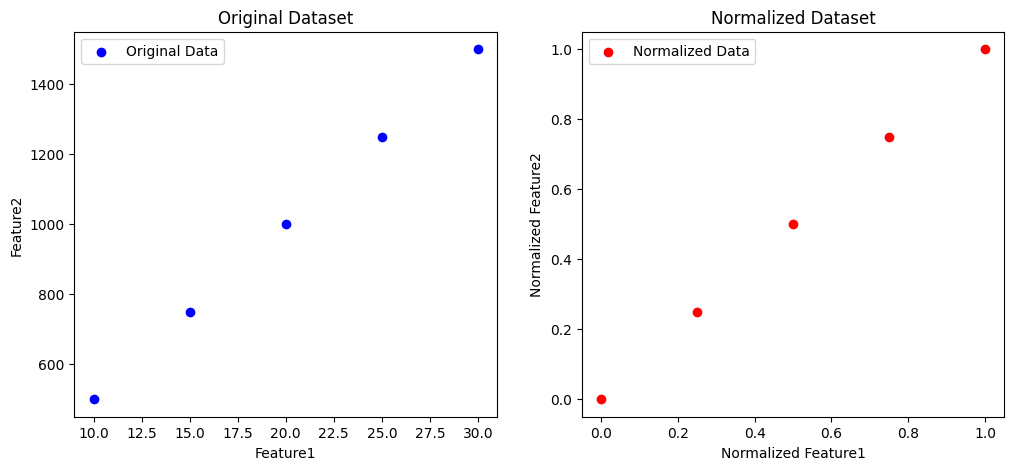

In [104]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Example dataset with numerical features
data = {
    'Feature1': [10, 20, 15, 25, 30],
    'Feature2': [500, 1000, 750, 1250, 1500]
}

df = pd.DataFrame(data)

# Apply Min-Max Scaling to normalize the features
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)

# Display the normalized dataset
normalized_df = pd.DataFrame(normalized_data, columns=df.columns)
print("Normalized Dataset:")
print(normalized_df)

# Plot original and normalized datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original dataset
ax1.scatter(df['Feature1'], df['Feature2'], c='blue', label='Original Data')
ax1.set_title('Original Dataset')
ax1.set_xlabel('Feature1')
ax1.set_ylabel('Feature2')
ax1.legend()

# Normalized dataset
ax2.scatter(normalized_df['Feature1'], normalized_df['Feature2'], c='red', label='Normalized Data')
ax2.set_title('Normalized Dataset')
ax2.set_xlabel('Normalized Feature1')
ax2.set_ylabel('Normalized Feature2')
ax2.legend()

plt.show()


    In this example, the MinMaxScaler from scikit-learn is used to normalize the numerical features in the dataset.

    Normalization is crucial for certain machine learning algorithms, especially those sensitive to the scale of the input features (e.g., k-nearest neighbors or support vector machines). The Min-Max Scaling example demonstrates how to normalize numerical features in a datase.

#### Example of Normalization in Python: Standardization (Z-score)

#### Explanation:

Standardization transforms the values of a feature so that it has a mean of 0 and a standard deviation of 1. Unlike Min-Max Scaling, the result is not limited to a fixed range. The formula for Standardization is: Xstandardized = (X − μ) / σ, where μ is the mean and σ is the standard deviation of the feature.

Standardized Dataset:
   Feature1  Feature2
0     -1.41     -1.41
1      0.00      0.00
2     -0.71     -0.71
3      0.71      0.71
4      1.41      1.41

Mean:
Feature1    0.0
Feature2    0.0
dtype: float64

Standard deviation:
Feature1    1.0
Feature2    1.0
dtype: float64


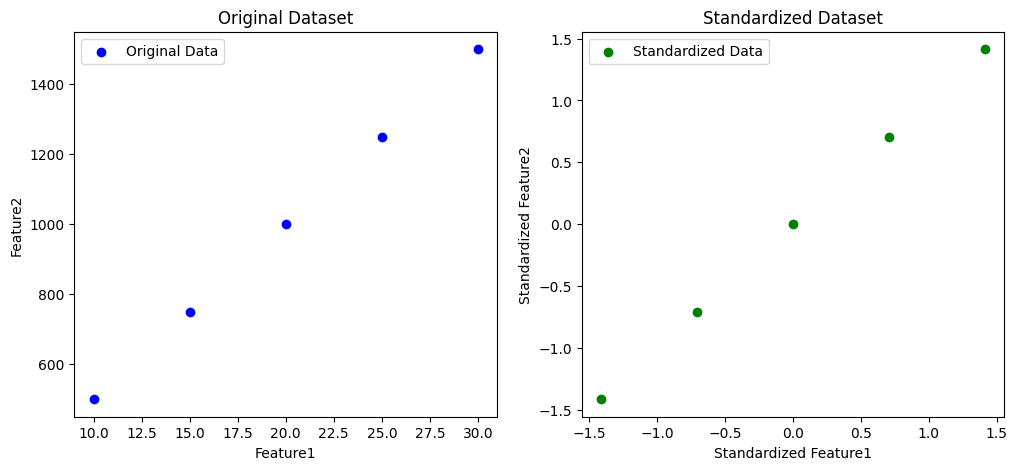

In [105]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Example dataset with numerical features
data = {
    'Feature1': [10, 20, 15, 25, 30],
    'Feature2': [500, 1000, 750, 1250, 1500]
}

df = pd.DataFrame(data)

# Apply Standardization (Z-score) to the features
scaler = StandardScaler()
standardized_data = scaler.fit_transform(df)

# Display the standardized dataset
standardized_df = pd.DataFrame(standardized_data, columns=df.columns)
print("Standardized Dataset:")
print(standardized_df.round(2))

# Check the result: mean is 0 and standard deviation is 1
print("\nMean:")
print(standardized_df.mean().round(2))
print("\nStandard deviation:")
print(standardized_df.std(ddof=0).round(2))

# Plot original and standardized datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original dataset
ax1.scatter(df['Feature1'], df['Feature2'], c='blue', label='Original Data')
ax1.set_title('Original Dataset')
ax1.set_xlabel('Feature1')
ax1.set_ylabel('Feature2')
ax1.legend()

# Standardized dataset
ax2.scatter(standardized_df['Feature1'], standardized_df['Feature2'], c='green', label='Standardized Data')
ax2.set_title('Standardized Dataset')
ax2.set_xlabel('Standardized Feature1')
ax2.set_ylabel('Standardized Feature2')
ax2.legend()

plt.show()

    In this example, the StandardScaler from scikit-learn is used to standardize the numerical features. After the transformation, both features have a mean of 0 and a standard deviation of 1, so a value tells how many standard deviations it lies above or below the mean. Note that StandardScaler uses the population standard deviation (ddof=0).

    Min-Max Scaling is suitable when the features need a fixed range (e.g. 0 to 1). Standardization is preferred when the data is roughly normally distributed, and for algorithms that assume centered data, such as PCA, logistic regression, or support vector machines. Both methods are sensitive to outliers, because an extreme value shifts the minimum/maximum or the mean/standard deviation. For data with many outliers, RobustScaler (which uses the median and interquartile range) is a better choice.

#### Example of Data Transformation in Python: Handling Skewed Data

#### Explanation:

A feature is skewed when its distribution is not symmetric. In a right-skewed (positively skewed) feature, most values are small and a few very large values form a long tail to the right, for example income, house prices, or transaction amounts. In a left-skewed (negatively skewed) feature, the long tail is on the left.

Skewness is measured with the skewness coefficient. A common rule of thumb:
- |skewness| < 0.5: approximately symmetric
- 0.5 ≤ |skewness| < 1: moderately skewed
- |skewness| ≥ 1: highly skewed

Scaling (Min-Max or Standardization) only shifts and stretches the values, so it does not change the shape of the distribution. To reduce skewness, a nonlinear transformation is applied:
- Log transformation: X' = log(X + 1) (log1p, so zeros are allowed)
- Square root transformation: X' = √X
- Cube root transformation: X' = ∛X (also works for negative values)
- Reciprocal transformation: X' = 1 / X (reverses the order of the values, not defined for X = 0)
- Box-Cox transformation: X' = (X^λ − 1) / λ for λ ≠ 0, and log(X) for λ = 0, where λ is estimated from the data (only for X > 0)
- Yeo-Johnson transformation: an extension of Box-Cox that also works for zero and negative values

count    1000.00
mean        5.97
std         5.49
min         0.24
25%         2.57
50%         4.50
75%         7.18
max        57.00
Name: Income, dtype: float64

Skewness: 3.12


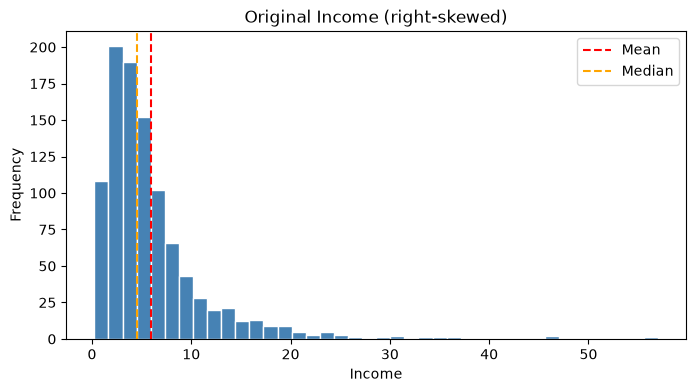

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example dataset with a right-skewed feature (monthly income in million rupiah)
rng = np.random.default_rng(42)
df = pd.DataFrame({
    'Income': rng.lognormal(mean=1.5, sigma=0.8, size=1000).round(2)
})

print(df['Income'].describe().round(2))
print("\nSkewness:", round(df['Income'].skew(), 2))

# Mean is pulled to the right by the long tail
plt.figure(figsize=(8, 4))
plt.hist(df['Income'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['Income'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Income'].median(), color='orange', linestyle='--', label='Median')
plt.title('Original Income (right-skewed)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Skewness:
Original       3.12
Log            0.41
Square root    1.27
Cube root      0.80
Reciprocal     4.04
dtype: float64


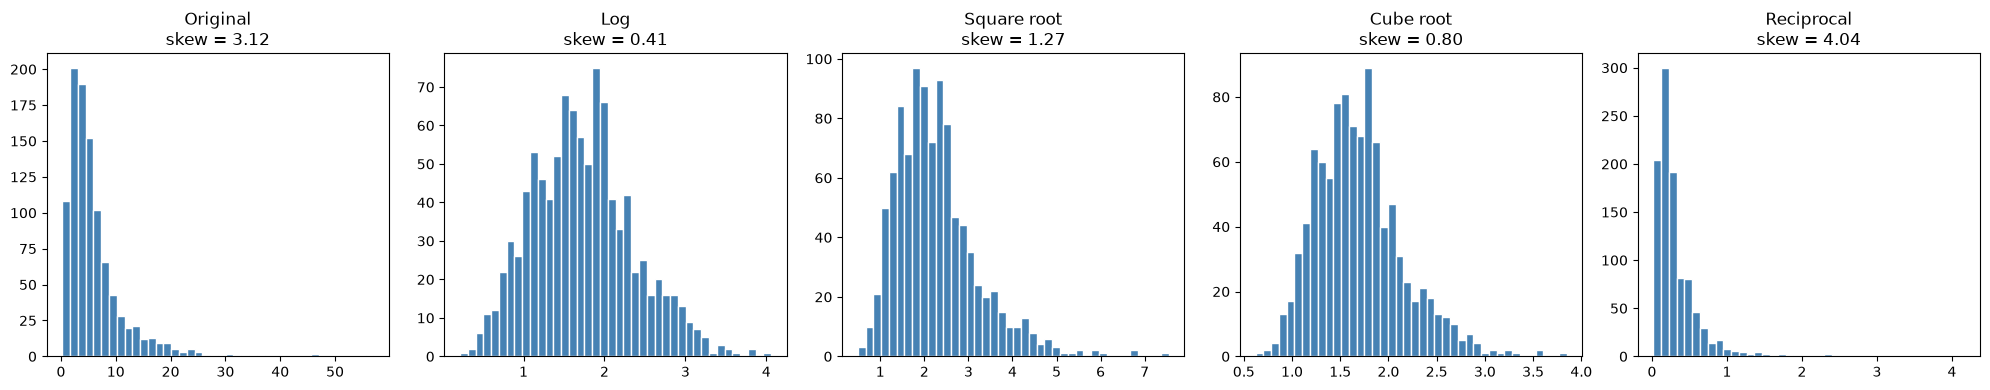

In [2]:
# 1. Simple mathematical transformations
transformed = pd.DataFrame({
    'Original': df['Income'],
    'Log': np.log1p(df['Income']),
    'Square root': np.sqrt(df['Income']),
    'Cube root': np.cbrt(df['Income']),
    'Reciprocal': 1 / df['Income']
})

# Compare skewness before and after each transformation
print("Skewness:")
print(transformed.skew().round(2))

# Plot the distribution after each transformation
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, transformed.columns):
    ax.hist(transformed[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f"{col}\nskew = {transformed[col].skew():.2f}")
plt.tight_layout()
plt.show()

Box-Cox lambda    : 0.018
Yeo-Johnson lambda: -0.234

Skewness Box-Cox    : 0.0
Skewness Yeo-Johnson: 0.01

Box-Cox error: The Box-Cox transformation can only be applied to strictly positive data


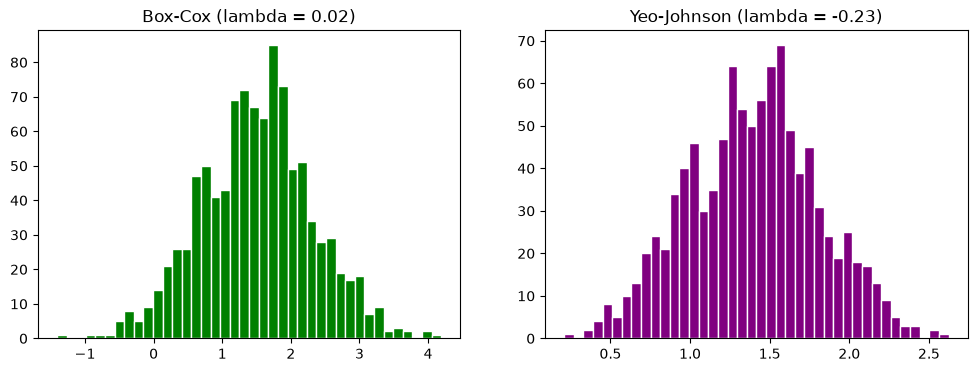

In [3]:
# 2. Power transformations: Box-Cox and Yeo-Johnson
from sklearn.preprocessing import PowerTransformer

# Box-Cox (only for strictly positive values)
boxcox = PowerTransformer(method='box-cox', standardize=False)
income_boxcox = boxcox.fit_transform(df[['Income']]).ravel()

# Yeo-Johnson (also works for zero and negative values)
yeojohnson = PowerTransformer(method='yeo-johnson', standardize=False)
income_yeojohnson = yeojohnson.fit_transform(df[['Income']]).ravel()

print("Box-Cox lambda    :", round(boxcox.lambdas_[0], 3))
print("Yeo-Johnson lambda:", round(yeojohnson.lambdas_[0], 3))
print("\nSkewness Box-Cox    :", round(pd.Series(income_boxcox).skew(), 2))
print("Skewness Yeo-Johnson:", round(pd.Series(income_yeojohnson).skew(), 2))

# Box-Cox fails on data with zero or negative values
try:
    PowerTransformer(method='box-cox').fit([[0.0], [1.0], [2.0]])
except ValueError as e:
    print("\nBox-Cox error:", e)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(income_boxcox, bins=40, color='green', edgecolor='white')
ax1.set_title(f"Box-Cox (lambda = {boxcox.lambdas_[0]:.2f})")
ax2.hist(income_yeojohnson, bins=40, color='purple', edgecolor='white')
ax2.set_title(f"Yeo-Johnson (lambda = {yeojohnson.lambdas_[0]:.2f})")
plt.show()

In [4]:
# 3. Left-skewed data: reflect first, then transform
# Example: exam scores where most students score high
scores = pd.Series(100 - rng.lognormal(mean=2, sigma=0.6, size=1000)).clip(lower=0).round(1)
print("Skewness original     :", round(scores.skew(), 2))

# Log directly on left-skewed data makes it even more skewed
print("Skewness log          :", round(np.log1p(scores).skew(), 2))

# Reflect (max + 1 - X) turns it into right-skewed data, then apply log
scores_reflected = scores.max() + 1 - scores
scores_log = np.log1p(scores_reflected)
print("Skewness reflect + log:", round(scores_log.skew(), 2))

Skewness original     : -1.96
Skewness log          : -2.42
Skewness reflect + log: 0.14


    In this example, the Income feature is highly right-skewed: the mean is larger than the median because a few very large incomes pull it to the right. The log transformation compresses large values much more than small ones, so the long tail shrinks and the distribution becomes close to symmetric. The square root and cube root are weaker transformations and suit moderately skewed data, so here they still leave the data skewed. The reciprocal makes this data even more skewed, because values close to 0 become very large (1 / 0.24 ≈ 4.2), so it should be used with care. Always check the skewness after a transformation instead of assuming it helped.

    Box-Cox and Yeo-Johnson do not require choosing the transformation by hand. PowerTransformer estimates the best λ from the data (λ close to 0 means the result is close to a log transformation). Box-Cox only accepts strictly positive values, so Yeo-Johnson is the safer choice when the feature contains zeros or negative values. With standardize=True (the default), PowerTransformer also standardizes the result to a mean of 0 and a standard deviation of 1.

    Log, square root, and Box-Cox only reduce right skewness. For left-skewed data, reflect the values first (max + 1 − X) so that the tail is on the right, then apply the transformation; remember that the order of the values is reversed. Skewness transformations are useful for algorithms that assume normally distributed data or are sensitive to large values, such as linear regression, logistic regression, and KNN. Tree-based models such as Decision Tree and Random Forest are generally not affected by skewness.

### 2.5.2. Discretization

Discretization is a data preprocessing technique that involves converting continuous numerical attributes into discrete categories or bins. This can be useful in situations where the continuous nature of the data is not necessary or when working with algorithms that perform better with categorical data. Discretization simplifies the data and can make it more suitable for certain types of analysis or modeling.

#### Example of Discretization in Python: Equal Width Binning

#### Explanation:

Equal Width Binning is a simple discretization method that divides the range of continuous values into equal-width intervals or bins. Each interval represents a discrete category, and values within that range are assigned to the corresponding bin.

In [106]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

# Example dataset with a continuous numerical feature
data = {
    'Age': [22, 35, 42, 28, 55, 48, 33, 40, 60, 70]
}

df = pd.DataFrame(data)

# Apply Equal Width Binning to discretize the 'Age' feature
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
discretized_data = discretizer.fit_transform(df)

# Display the discretized dataset
discretized_df = pd.DataFrame(discretized_data, columns=df.columns)
print("Discretized Dataset:")
print(discretized_df)


Discretized Dataset:
   Age
0  0.0
1  0.0
2  1.0
3  0.0
4  2.0
5  1.0
6  0.0
7  1.0
8  2.0
9  2.0


    In this example, the KBinsDiscretizer from scikit-learn is used to apply equal-width binning to the 'Age' feature, dividing it into three bins.

    Discretization is valuable when working with algorithms that require categorical input or when simplifying the analysis of continuous data. The Equal Width Binning example demonstrates how to discretize a numerical feature into categorical bins.

### 2.5.3. Data compression

Data compression is a process of reducing the size or volume of data to save storage space and improve computational efficiency. In the context of data mining, compression techniques can be applied to handle large datasets more efficiently, speed up processing, and reduce the resource requirements for storage and transmission.

#### Example of Data Compression in Python: Run-Length Encoding

#### Explanation:

Run-Length Encoding (RLE) is a simple data compression technique that represents consecutive repeated values as a single value and a count. It is particularly effective for datasets with long runs of identical values.

In [107]:
def run_length_encoding(data):
    encoded_data = []
    count = 1

    for i in range(1, len(data)):
        if data[i] == data[i - 1]:
            count += 1
        else:
            encoded_data.append((data[i - 1], count))
            count = 1

    # Add the last run
    encoded_data.append((data[-1], count))
    return encoded_data

# Example dataset with consecutive repeated values
data = [1, 1, 1, 2, 3, 3, 3, 3, 4, 4]

# Apply Run-Length Encoding to compress the data
compressed_data = run_length_encoding(data)

# Display the compressed data
print("Compressed Data:")
print(compressed_data)


Compressed Data:
[(1, 3), (2, 1), (3, 4), (4, 2)]


    In this example, the run_length_encoding function is used to compress a dataset with consecutive repeated values using Run-Length Encoding.

    Data compression is beneficial for reducing storage requirements and speeding up data processing. While Run-Length Encoding is a basic example, there are more advanced compression techniques like Huffman coding or Lempel-Ziv compression.

### 2.5.4. Sampling

Sampling is a data preprocessing technique that involves selecting a subset of data from a larger dataset. This subset, known as a sample, is representative of the overall population and is often used for various purposes, such as exploratory analysis, model training, or performance testing. Sampling can be particularly valuable when working with large datasets, as it allows for more efficient processing and analysis of a manageable subset.

#### Example of Sampling in Python: Random Sampling

#### Explanation:

Random Sampling is a common sampling technique where data points are selected randomly from the dataset, providing an unbiased representation of the population.

In [108]:
import pandas as pd
import numpy as np

# Example dataset
data = {
    'ID': range(1, 101),
    'Value': np.random.randint(1, 100, size=100)
}

df = pd.DataFrame(data)

# Perform random sampling to select a subset of data
sample_size = 20
random_sample = df.sample(n=sample_size, random_state=42)

# Display the randomly sampled data
print("Randomly Sampled Data:")
print(random_sample)


Randomly Sampled Data:
    ID  Value
83  84     51
53  54     19
70  71     65
45  46     69
44  45     70
39  40     58
22  23     57
80  81     30
10  11     85
0    1     75
18  19     54
30  31     71
73  74     30
33  34     50
90  91     57
4    5     20
76  77     40
77  78     89
12  13     59
31  32      8


    In this example, the sample function from pandas is used to perform random sampling on a dataset. The random_state parameter ensures reproducibility.

    Sampling is essential when dealing with large datasets to make computations more manageable and to speed up the analysis process. Random Sampling is just one of many sampling methods.

## Section 2.6

### 2.6.1. Principal components analysis

Principal Components Analysis (PCA) is a dimensionality reduction technique used to transform a dataset into a lower-dimensional space while retaining as much of the original variance as possible. PCA identifies the principal components, which are orthogonal vectors that capture the directions of maximum variance in the data. By projecting the data onto these components, PCA allows for a more concise representation of the dataset, making it easier to visualize and analyze.

#### Example of Principal Components Analysis in Python:

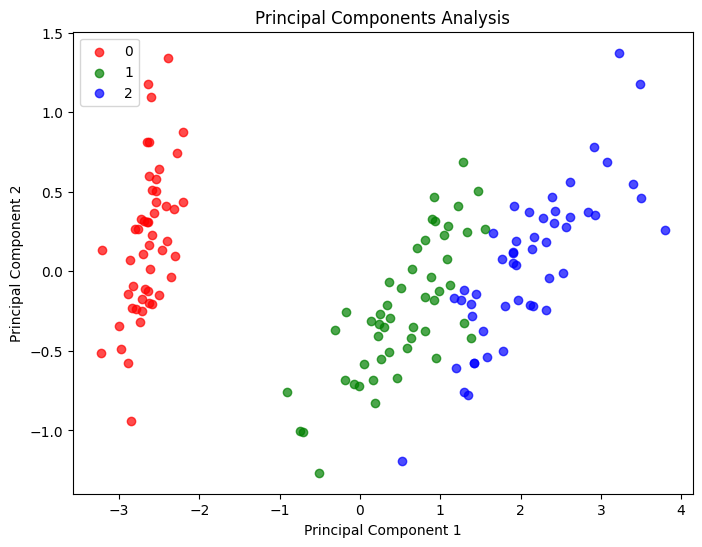

In [109]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Example dataset
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
target = pd.Series(data=iris.target, name='target')

# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a DataFrame with the principal components and target
pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pc_df['target'] = target

# Plot the data in the reduced dimensional space
plt.figure(figsize=(8, 6))
targets = [0, 1, 2]
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indices_to_keep = pc_df['target'] == target
    plt.scatter(pc_df.loc[indices_to_keep, 'PC1'],
                pc_df.loc[indices_to_keep, 'PC2'],
                c=color,
                label=target,
                alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Principal Components Analysis')
plt.legend()
plt.show()


In [110]:
data.shape

(150, 4)

    In this example, PCA is applied to the Iris dataset, which contains measurements of sepal length, sepal width, petal length, and petal width for three species of iris flowers. The code reduces the dimensionality to two principal components and visualizes the data in the reduced space.

    PCA is widely used for feature reduction, noise reduction, and visualization. The example demonstrates how PCA can be applied to simplify and visualize high-dimensional data.

### 2.6.2. Attribute subset selection

Attribute subset selection, also known as feature selection, involves identifying and selecting a subset of relevant features from the original set of attributes in a dataset. The goal is to improve model performance, reduce dimensionality, and enhance interpretability by retaining only the most informative attributes. This process is crucial for addressing the "curse of dimensionality" and can lead to more efficient and accurate data mining models.

#### Example of Attribute Subset Selection in Python:

In [111]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Example dataset
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
target = pd.Series(data=iris.target, name='target')

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Apply RandomForestClassifier for feature selection
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Select features based on importance
sfm = SelectFromModel(clf, threshold=0.2)
sfm.fit(X_train, y_train)

# Transform datasets with selected features
X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)

print(X_train_selected)

# Train and evaluate a classifier with the selected features
clf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
clf_selected.fit(X_train_selected, y_train)
y_pred_selected = clf_selected.predict(X_test_selected)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_selected)
print(f'Accuracy with selected features: {accuracy * 100:.2f}%')


[[1.  0.2]
 [1.5 0.4]
 [4.4 1.4]
 [1.6 0.2]
 [1.3 0.2]
 [5.  1.9]
 [4.5 1.5]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [5.1 1.9]
 [4.5 1.6]
 [4.7 1.5]
 [1.3 0.4]
 [1.5 0.2]
 [3.7 1. ]
 [5.1 1.5]
 [5.5 1.8]
 [4.4 1.4]
 [6.1 2.5]
 [4.2 1.3]
 [6.6 2.1]
 [4.5 1.5]
 [1.4 0.2]
 [6.7 2. ]
 [4.1 1. ]
 [1.4 0.2]
 [1.3 0.3]
 [1.9 0.4]
 [3.5 1. ]
 [4.9 1.8]
 [1.9 0.2]
 [1.6 0.2]
 [1.7 0.5]
 [4.2 1.3]
 [1.5 0.2]
 [4.2 1.2]
 [6.7 2.2]
 [1.4 0.2]
 [4.3 1.3]
 [5.  2. ]
 [1.4 0.2]
 [4.8 1.8]
 [5.1 1.9]
 [4.  1. ]
 [4.5 1.5]
 [5.4 2.3]
 [4.  1.3]
 [1.7 0.4]
 [3.3 1. ]
 [5.3 1.9]
 [1.4 0.2]
 [1.2 0.2]
 [3.8 1.1]
 [5.  1.7]
 [1.5 0.2]
 [5.1 2.4]
 [1.5 0.2]
 [1.6 0.6]
 [4.8 1.8]
 [3.  1.1]
 [5.7 2.3]
 [5.1 1.6]
 [5.6 1.4]
 [6.1 2.3]
 [4.  1.3]
 [1.4 0.2]
 [1.1 0.1]
 [5.  1.5]
 [6.  1.8]
 [1.5 0.2]
 [1.4 0.3]
 [1.3 0.2]
 [4.9 1.5]
 [5.6 2.4]
 [1.4 0.3]
 [5.5 2.1]
 [6.  2.5]
 [1.3 0.2]
 [4.7 1.4]
 [4.6 1.5]
 [4.8 1.8]
 [4.7 1.4]
 [5.3 2.3]
 [1.6 0.2]
 [5.4 2.1]
 [4.2 1.5]
 [5.2 2. ]
 [3.5 1. ]
 [3.9 1.4]
 [4.6 1.4]

In [112]:
data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [113]:
clf.feature_importances_

array([0.10809762, 0.03038681, 0.43999397, 0.42152159])

    In this example, a RandomForestClassifier is used to assess feature importance, and SelectFromModel is applied to select features based on their importance. The classifier is then trained and evaluated using only the selected features.

    Attribute subset selection is crucial for improving model efficiency, reducing overfitting, and enhancing interpretability. The example demonstrates how to apply attribute subset selection using feature importance from a random forest classifier.

### 2.6.3. Nonlinear dimensionality reduction methods

Nonlinear dimensionality reduction methods aim to capture complex relationships and structures in high-dimensional data that may not be well-represented by linear techniques like PCA. These methods transform data into a lower-dimensional space while preserving the inherent nonlinear relationships within the data. Nonlinear dimensionality reduction is particularly useful when dealing with datasets containing intricate patterns, clusters, or manifolds.

#### Example of Nonlinear Dimensionality Reduction in Python: t-Distributed Stochastic Neighbor Embedding (t-SNE)

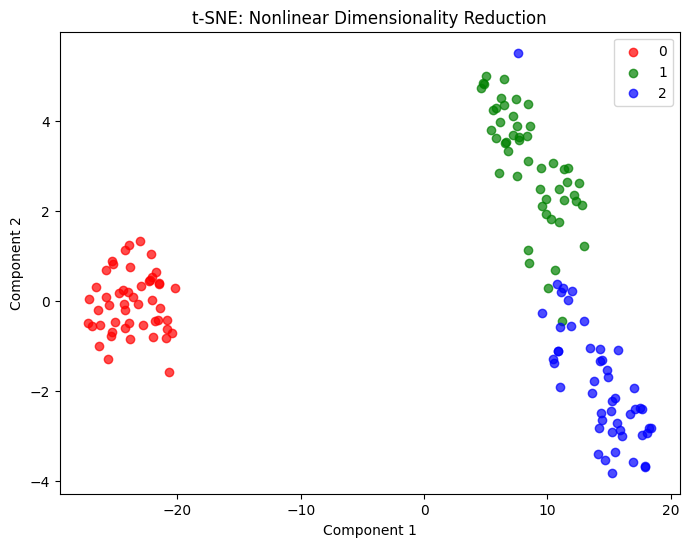

In [114]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Example dataset
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
target = pd.Series(data=iris.target, name='target')

# Apply t-SNE for nonlinear dimensionality reduction to 2 components
tsne = TSNE(n_components=2, random_state=42)
embedded_data = tsne.fit_transform(data)

# Create a DataFrame with the embedded data and target
embedded_df = pd.DataFrame(data=embedded_data, columns=['Component 1', 'Component 2'])
embedded_df['target'] = target

# Plot the data in the reduced dimensional space
plt.figure(figsize=(8, 6))
targets = [0, 1, 2]
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indices_to_keep = embedded_df['target'] == target
    plt.scatter(embedded_df.loc[indices_to_keep, 'Component 1'],
                embedded_df.loc[indices_to_keep, 'Component 2'],
                c=color,
                label=target,
                alpha=0.7)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('t-SNE: Nonlinear Dimensionality Reduction')
plt.legend()
plt.show()


In [115]:
tsne.kl_divergence_

0.12693068385124207

    In this example, t-SNE is applied to the Iris dataset, and the data is visualized in a two-dimensional space. t-SNE is known for preserving local similarities, making it effective for capturing intricate structures and patterns in the data.

    Nonlinear dimensionality reduction methods, like t-SNE, are valuable for visualizing and understanding complex relationships in high-dimensional data. The example introduces how t-SNE can be used for nonlinear dimensionality reduction and visualization.